## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import RobustScaler, OrdinalEncoder,LabelEncoder
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier

from module_function import (cross_validate_model,evalute_models_classification,feature_importance,plot_residuals,
                             Hyperparameter_Tuning,plot_tuned_feature_importance,plot_confusion_matrix,plot_roc_curves)

import warnings
warnings.filterwarnings("ignore")
import pickle

In [2]:
df = pd.read_csv('dataset/diabetic_Binnary_CLEANING.csv',nrows=50000)
df_x = df.drop(columns='readmitted')
df_y = df['readmitted']

In [3]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,stratify=df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 40000 samples
Test set: 10000 samples


## 2.Feature Scaling

In [4]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print("--- Hasil Pemetaan Label Encoding ---")
for index, kelas in enumerate(target_encoder.classes_):
    print(f"Kategori: '{kelas}' diubah menjadi angka -> {index}")

--- Hasil Pemetaan Label Encoding ---
Kategori: 'NO' diubah menjadi angka -> 0
Kategori: 'readmitted' diubah menjadi angka -> 1


## 3.Pipeline All Models Classification

In [5]:
n = 30
classification_pipelines = {
    'Logistic Regression (Baseline)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    
    'Random Forest Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1))
    ]),
    
    'Extra Trees Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', ExtraTreesClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced'))
    ]),
    
    'XGBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.1, eval_metric='mlogloss', n_jobs=-1))
    ]),
    
    'LightGBM Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1, n_jobs=-1, verbose=-1))
    ]),
    
    'CatBoost Classifier': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', CatBoostClassifier(random_state=42, iterations=100, learning_rate=0.1, verbose=0))
    ]),
    
    'Hist Gradient Boosting': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', HistGradientBoostingClassifier(random_state=42, max_iter=100, learning_rate=0.1))
    ]),
    
    'Support Vector Classifier (SVC)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', SVC(random_state=42, probability=True, kernel='rbf', class_weight='balanced'))
    ]),

    'K-Nearest Neighbors (KNN)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('smoteenn',RandomUnderSampler(random_state=42)),
        ('feature_selection', SelectKBest(score_func=f_classif, k=n)),
        ('model', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [6]:
predictions_dict = {}
for model_name, pipeline in classification_pipelines.items():
    pipeline.fit(X_train, y_train_encoded)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evalute_models_classification( model_dict=predictions_dict, y_test=y_test_encoded,averages='macro')
df_report.sort_values(by='Accuracy', ascending=False)

Menguji model: Logistic Regression (Baseline)
=== CLASSIFICATION REPORT: Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       0.63      0.68      0.65      5696
           1       0.53      0.48      0.50      4304

    accuracy                           0.59     10000
   macro avg       0.58      0.58      0.58     10000
weighted avg       0.59      0.59      0.59     10000



Menguji model: Random Forest Classifier
=== CLASSIFICATION REPORT: Random Forest Classifier ===
              precision    recall  f1-score   support

           0       0.63      0.58      0.60      5696
           1       0.49      0.54      0.52      4304

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.57      0.56      0.57     10000



Menguji model: Extra Trees Classifier
=== CLASSIFICATION REPORT: Extra Trees Classifier ===
              precision    recall  f1-score   

,Model,Accuracy,Precision,Recall,F1-Score
7,Support Vector Classifier (SVC),0.6015,0.587690,0.575186,0.570390
5,CatBoost Classifier,0.5943,0.586632,0.586809,0.586712
0,Logistic Regression (Baseline),0.5917,0.580426,0.578195,0.578418
3,XGBoost Classifier,0.5917,0.585841,0.586741,0.586004
4,LightGBM Classifier,0.5908,0.585736,0.586859,0.585788
6,Hist Gradient Boosting,0.5905,0.585581,0.586738,0.585604
1,Random Forest Classifier,0.5645,0.561008,0.562041,0.560458
2,Extra Trees Classifier,0.5581,0.554873,0.555827,0.554186
8,K-Nearest Neighbors (KNN),0.5521,0.550124,0.551071,0.548910


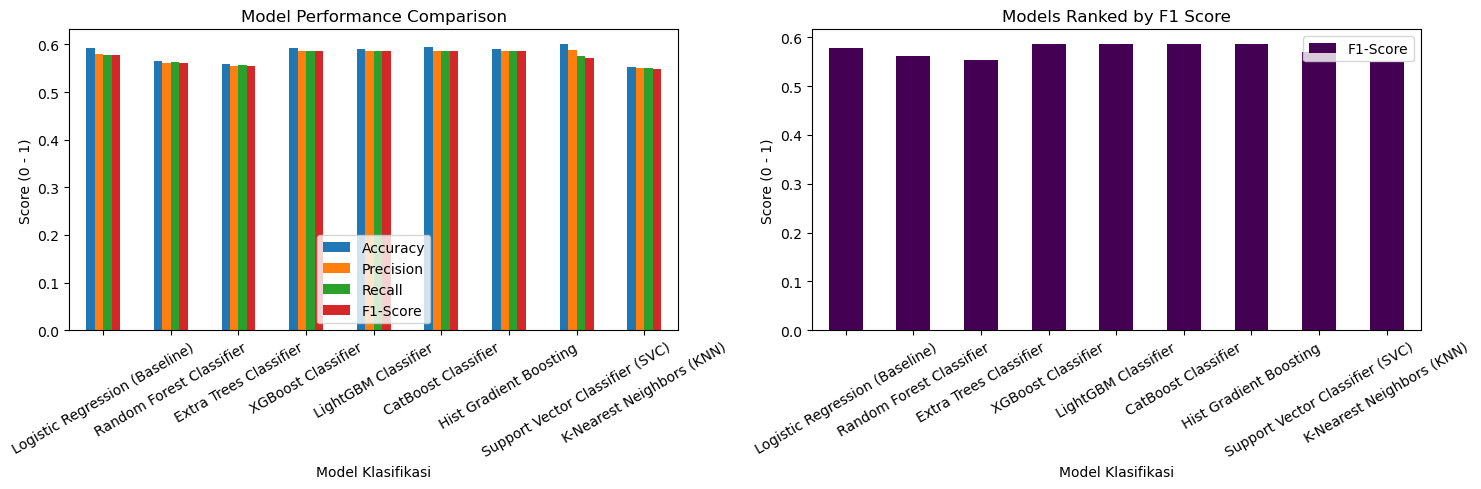

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'Precision','Recall','F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['F1-Score']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Models Ranked by F1 Score', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

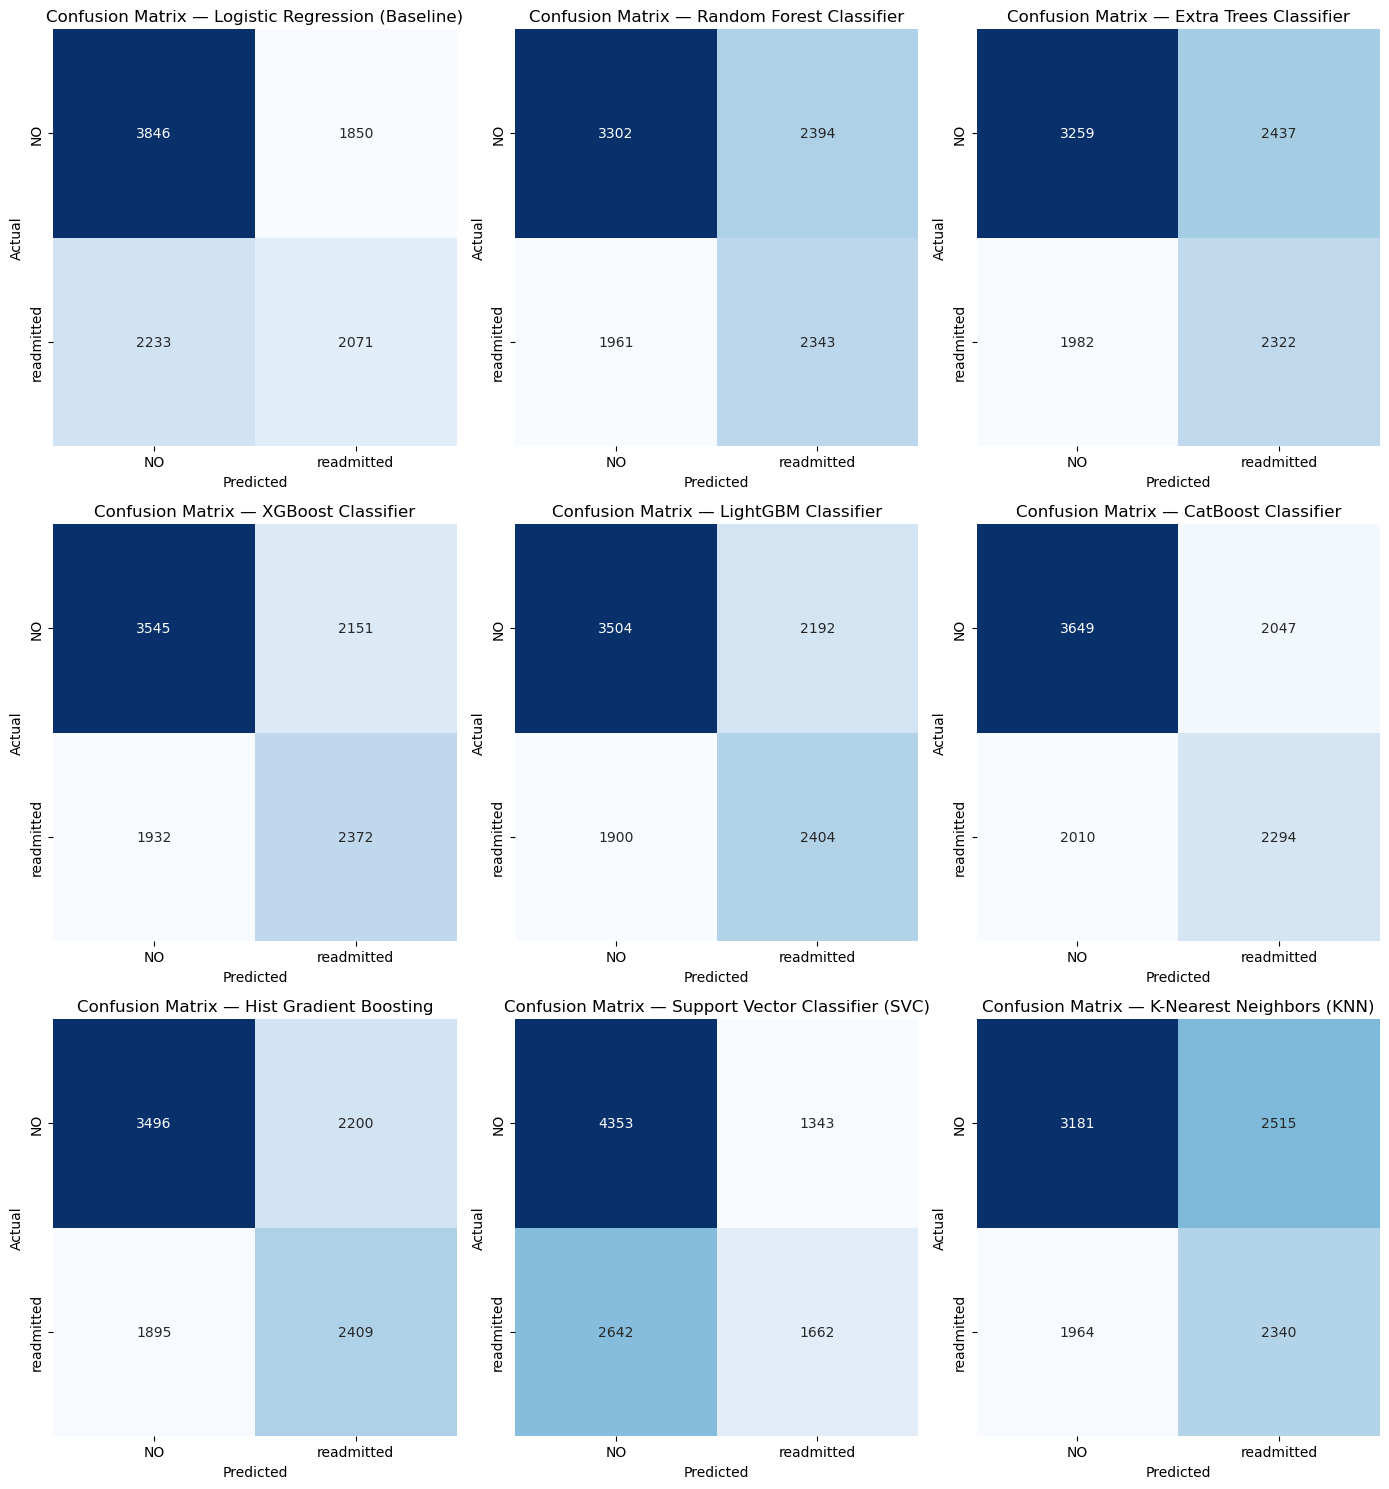

In [8]:
label = list(target_encoder.classes_)
plot_confusion_matrix(model_dict=predictions_dict,y_test=y_test_encoded,labels=label)

## 5.Analysis Model Sesudah Cross-Validate

In [9]:
df_hasil_perbandingan = cross_validate_model(models_dict=classification_pipelines, X=X_train, y=y_train_encoded, cv_folds=5, mode='classification')
df_hasil_perbandingan.sort_values(by='Accuracy', ascending=False)

=== MENJALANKAN STRATIFIED 5-FOLD CROSS VALIDATION (KLASIFIKASI) ===

Menguji model: Logistic Regression (Baseline)
Menguji model: Random Forest Classifier
Menguji model: Extra Trees Classifier
Menguji model: XGBoost Classifier
Menguji model: LightGBM Classifier
Menguji model: CatBoost Classifier
Menguji model: Hist Gradient Boosting
Menguji model: Support Vector Classifier (SVC)
Menguji model: K-Nearest Neighbors (KNN)

Proses CV Selesai!


,Model,Accuracy,Precision,Recall,F1-Score
7,Support Vector Classifier (SVC),0.607700,0.595190,0.581457,0.576895
5,CatBoost Classifier,0.600925,0.593014,0.592998,0.592997
0,Logistic Regression (Baseline),0.598025,0.587036,0.584495,0.584732
6,Hist Gradient Boosting,0.596800,0.590239,0.590851,0.590361
4,LightGBM Classifier,0.596675,0.591050,0.592047,0.591189
3,XGBoost Classifier,0.595600,0.589815,0.590749,0.589971
1,Random Forest Classifier,0.573400,0.569019,0.570039,0.568749
2,Extra Trees Classifier,0.566800,0.562946,0.563962,0.562518
8,K-Nearest Neighbors (KNN),0.543100,0.541070,0.541830,0.539788


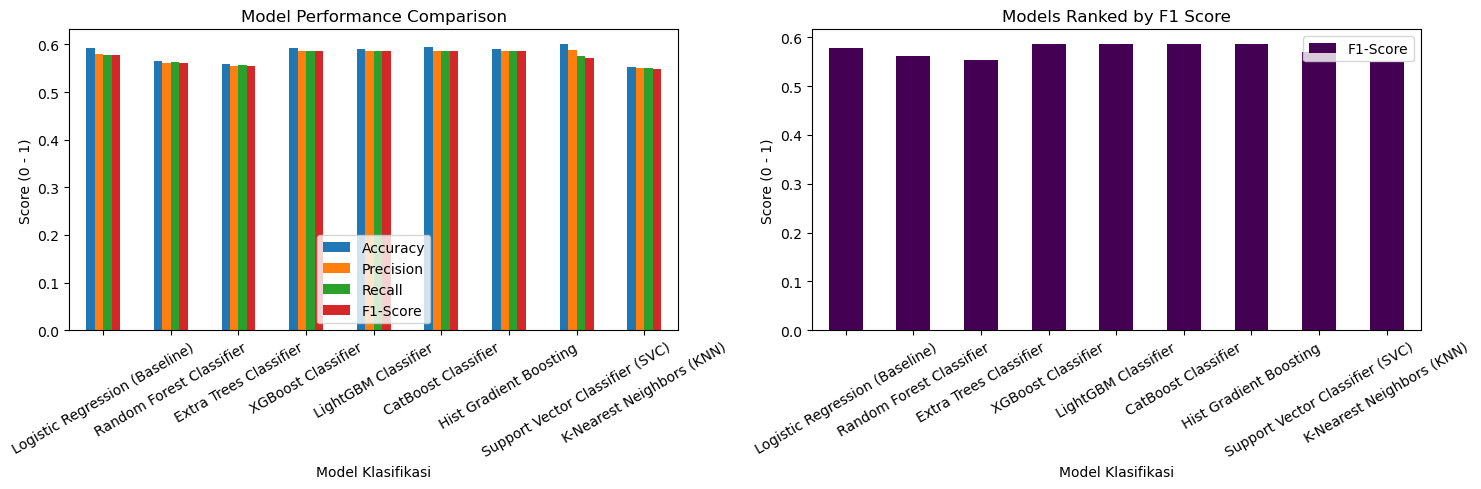

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['Accuracy', 'Precision','Recall','F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison', fontsize=12)
axes[0].set_ylabel('Score (0 - 1)')
axes[0].set_xlabel('Model Klasifikasi')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['F1-Score']].plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Models Ranked by F1 Score', fontsize=12)
axes[1].set_ylabel('Score (0 - 1)')
axes[1].set_xlabel('Model Klasifikasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

Deteksi: y_test berupa string/teks. Melakukan Label Encoding otomatis...


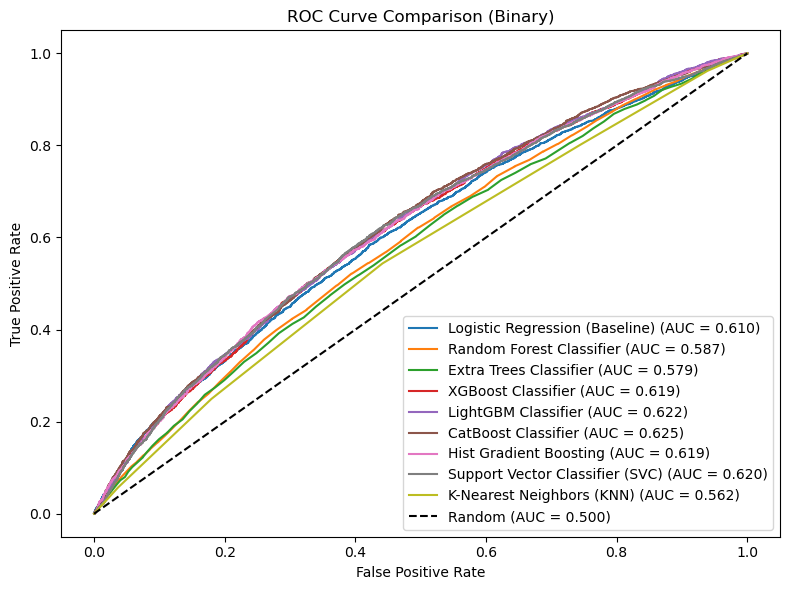

In [11]:
plot_roc_curves(model_dict=classification_pipelines, X_test=X_test, y_train=y_train, y_test=y_test)

## 7. Importance Feature for Models

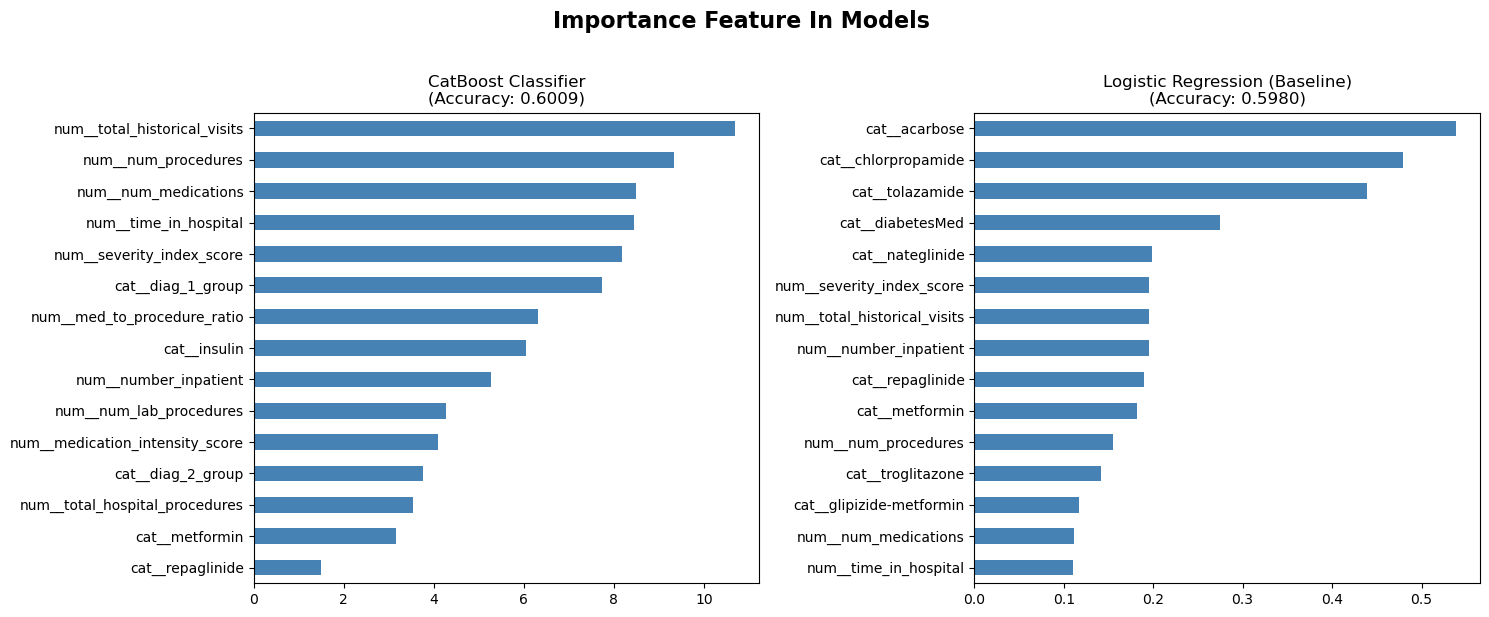

In [12]:
target_models = ['Logistic Regression (Baseline)', 'CatBoost Classifier']
feature_importance(result_crossValidate=df_hasil_perbandingan[df_hasil_perbandingan['Model'].isin(target_models)],model_dict=classification_pipelines)

## 8. Hyperparameter Tuning — CatBoost Classifier

Deteksi Binary. Menggunakan metrik: 'roc_auc'


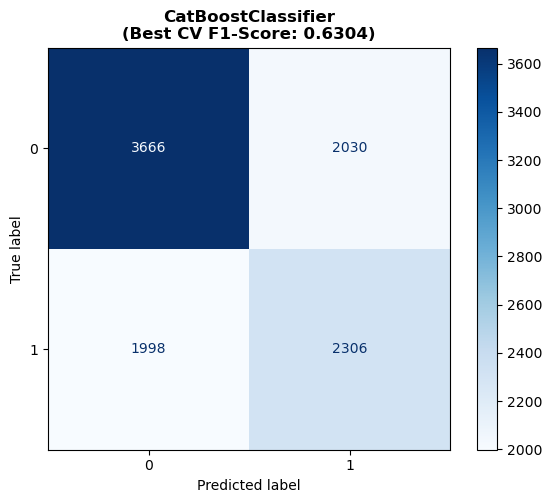

In [13]:
pipeline_model = classification_pipelines['CatBoost Classifier']
params ={
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__iterations': [500, 1000, 1500],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__random_strength': [0, 1, 2]
}
best_model = Hyperparameter_Tuning(method='randomcv',pipeline_model=pipeline_model,cv=5,type_model='classification',
                                   param=params,x_train=X_train,y_train=y_train_encoded,x_test=X_test,y_test=y_test_encoded)

## 9. Tuned Model — Feature Importance

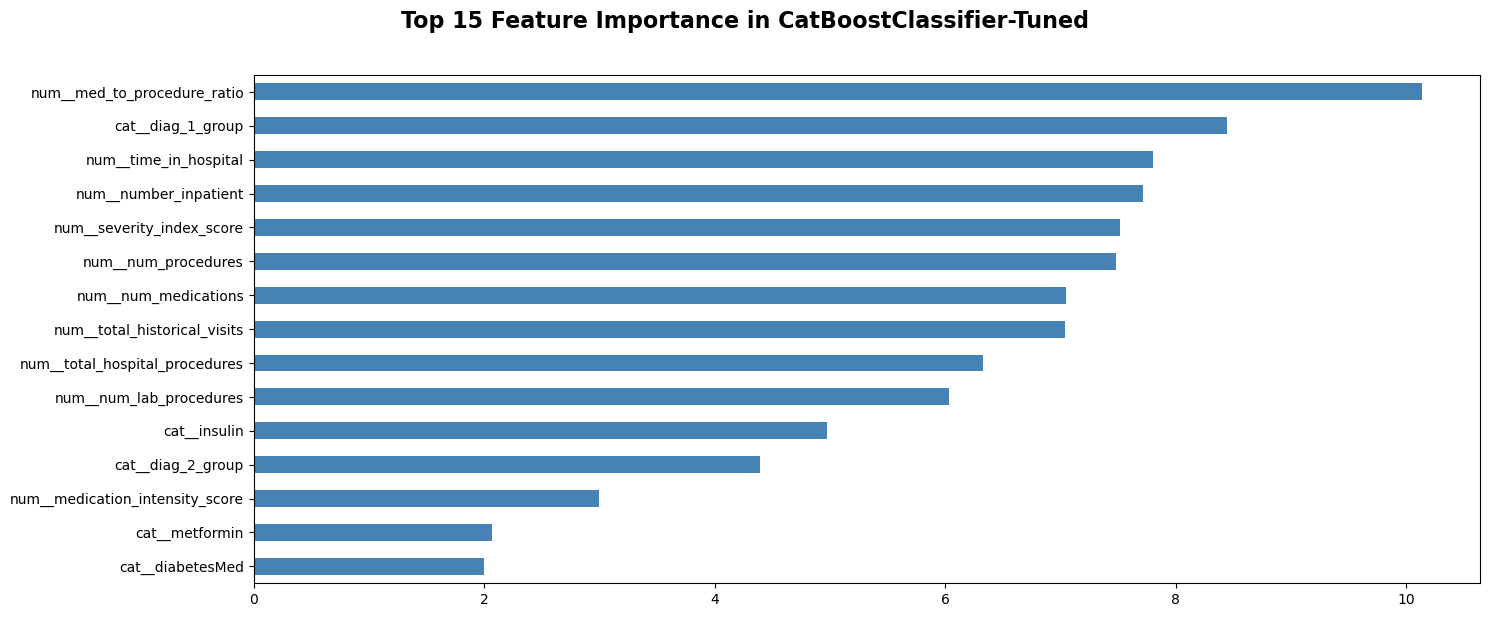

In [14]:
plot_tuned_feature_importance(tuned_model=best_model)

## 10. Simple Prediction

In [15]:
sample = X_test.iloc[:20].copy()
preds = best_model.predict(sample).flatten() 
preds_proba = (best_model.predict_proba(sample)).round(2)

result = pd.DataFrame({
    'Predict' : preds,
    'Actual': y_test_encoded[:20],
    'Peluang Aman (%)' : preds_proba[:,0] * 100,
    'Peluang Terkena (%)' : (preds_proba[:,1] * 100).round(2)
})
result

,Predict,Actual,Peluang Aman (%),Peluang Terkena (%)
0,1,1,34.0,66.0
1,0,0,53.0,47.0
2,1,0,40.0,60.0
3,1,0,34.0,66.0
4,0,0,52.0,48.0
5,1,0,30.0,70.0
6,0,0,52.0,48.0
7,1,1,50.0,50.0
8,0,0,55.0,45.0
9,0,0,54.0,46.0
